# Notebook 3: Census Data Integration with censusdis

**CCOM 6994: Data Analysis Tools - Final Project**  
**Course: Análisis de Datos de Paneles Solares**

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1.  **Discover Census Datasets**: Programmatically list available datasets and variables using `censusdis`.
2.  **Fetch Demographic Data**: Retrieve ACS 5-Year Estimates for the entire US and Puerto Rico.
3.  **Visualize Spatial Data**: Create choropleth maps to analyze income distribution.
4.  **Persist Data**: Save census data to DuckDB for later integration with solar panel data.

## 📚 References & Documentation

-   [censusdis Introduction](https://censusdis.readthedocs.io/en/latest/intro.html)
-   [Querying Available Data Sets](https://github.com/censusdis/censusdis/blob/main/notebooks/Querying%20Available%20Data%20Sets.ipynb)
-   [Lesson 1: Basic Queries](https://github.com/censusdis/censusdis-tutorial-2024/blob/main/Lessons/Lesson%201%20Basic%20Queries.ipynb)
-   [Lesson 2: Maps](https://github.com/censusdis/censusdis-tutorial-2024/blob/main/Lessons/Lesson%202%20Maps.ipynb)
-   [Lesson 3: Variables](https://github.com/censusdis/censusdis-tutorial-2024/blob/main/Lessons/Lesson%203%20Variables.ipynb)
-   [Population Change 2020-2021](https://censusdis.readthedocs.io/en/latest/nb/Population%20Change%202020-2021.html#Part-2:-Using-the-Population-Estimates-Dataset)

---

## 🔧 Setup: Import Libraries

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from dotenv import load_dotenv

# censusdis imports
import censusdis.data as ced
import censusdis.states as states
import censusdis.datasets as ced_datasets

# Load environment variables
load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), '.env'))

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


---

## 🔍 Part 1: Discovering Data

The US Census Bureau provides a vast amount of data. `censusdis` makes it easy to explore what's available.

### 1.1 Listing Available Datasets

We can check which datasets are available for a given vintage (year).

In [2]:
print("🔍 Available Datasets for 2020:")
# Note: This might print a lot of output, so we just show a few common ones manually or use the API if available
# censusdis doesn't have a simple "list all" function that returns a clean list, but we can look at the constants.

# Common Datasets:
# - acs/acs5: American Community Survey 5-Year Estimates (Most detailed, small areas)
# - acs/acs1: American Community Survey 1-Year Estimates (More current, large areas)
# - dec/pl: Decennial Census (Official count, every 10 years)

print("   • acs/acs5: American Community Survey 5-Year Estimates")
print("   • acs/acs1: American Community Survey 1-Year Estimates")
print("   • dec/pl: Decennial Census P.L. 94-171 Redistricting Data")

🔍 Available Datasets for 2020:
   • acs/acs5: American Community Survey 5-Year Estimates
   • acs/acs1: American Community Survey 1-Year Estimates
   • dec/pl: Decennial Census P.L. 94-171 Redistricting Data


### 1.2 Finding Variables

Census variables have codes like `B19013_001E`. We can search for them using keywords.

Let's find variables related to **"Median Household Income"** and **"Total Population"**.

In [ ]:
# We want to find the variable ID for "Median Household Income"
# In a real workflow, we might use ced.variables.search() if available, or look up on Census Reporter.

# Key Variables we will use:
# B01003_001E: Total Population
# B19013_001E: Median Household Income in the Past 12 Months (Inflation-Adjusted)



VARIABLES = {
    'B01003_001E': 'Total_Population',
    'B19013_001E': 'Median_Household_Income'
}

print(f"🎯 Selected Variables: {VARIABLES}")

🎯 Selected Variables: {'B01003_001E': 'Total_Population', 'B19013_001E': 'Median_Household_Income'}


---

## 📥 Part 2: Fetching Census Data (US + Puerto Rico)

We will fetch data for **all US States** and **Puerto Rico** (State '72').

We will fetch two levels of geography:
1.  **State Level**: For broad national trends.
2.  **County Level**: For more granular analysis.

**Dataset**: ACS 5-Year Estimates (`acs/acs5`)
**Vintage**: 2020

In [4]:
# Define the dataset and vintage
DATASET = 'acs/acs5'
VINTAGE = 2020

### 2.1 Fetching State-Level Data

We use `state='*'` to get all states.

In [5]:
print("📥 Fetching State-Level Data (US + PR)...")

gdf_state = ced.download(
    dataset=DATASET,
    vintage=VINTAGE,
    download_variables=list(VARIABLES.keys()),
    state='*',
    with_geometry=True
)

# Rename columns
gdf_state = gdf_state.rename(columns=VARIABLES)

print(f"✅ Fetched {len(gdf_state)} states/territories.")
display(gdf_state.head())

📥 Fetching State-Level Data (US + PR)...
✅ Fetched 52 states/territories.


,STATE,Total_Population,Median_Household_Income,geometry
0,42,12794885,63627,"POLYGON ((-80.51989 40.90666, -80.51963 40.911..."
1,06,39346023,78672,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."
2,54,1807426,48037,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."
3,49,3151239,74197,"POLYGON ((-114.05296 37.59278, -114.05247 37.6..."
4,36,19514849,71117,"MULTIPOLYGON (((-79.76215 42.24305, -79.76196 ..."


### 2.2 Fetching County-Level Data

We fetch data for all counties in all states. This is a larger request.

In [6]:
print("📥 Fetching County-Level Data (All US Counties)...")

# Note: Fetching all counties for all states might take a moment.
gdf_county = ced.download(
    dataset=DATASET,
    vintage=VINTAGE,
    download_variables=list(VARIABLES.keys()),
    state='*',
    county='*',
    with_geometry=True
)

# Rename columns
gdf_county = gdf_county.rename(columns=VARIABLES)

print(f"✅ Fetched {len(gdf_county):,} counties.")
display(gdf_county.head())

📥 Fetching County-Level Data (All US Counties)...
✅ Fetched 3,221 counties.


,STATE,COUNTY,Total_Population,Median_Household_Income,geometry
0,01,001,55639,57982.0,"POLYGON ((-86.9212 32.65754, -86.92035 32.6585..."
1,01,003,218289,61756.0,"POLYGON ((-88.02858 30.22676, -88.02399 30.230..."
2,01,005,25026,34990.0,"POLYGON ((-85.74803 31.61918, -85.74544 31.618..."
3,01,007,22374,51721.0,"POLYGON ((-87.42194 33.00338, -87.33177 33.005..."
4,01,009,57755,48922.0,"POLYGON ((-86.96336 33.85822, -86.95967 33.857..."


---

## 🗺️ Part 3: Visualizing Census Data

Let's visualize the **Median Household Income** across the US.

We will create a choropleth map. To make it readable, we'll focus on the contiguous US (excluding AK, HI, PR for the main map, or plotting them separately).

🗺️ Visualizing Median Household Income (State Level)...


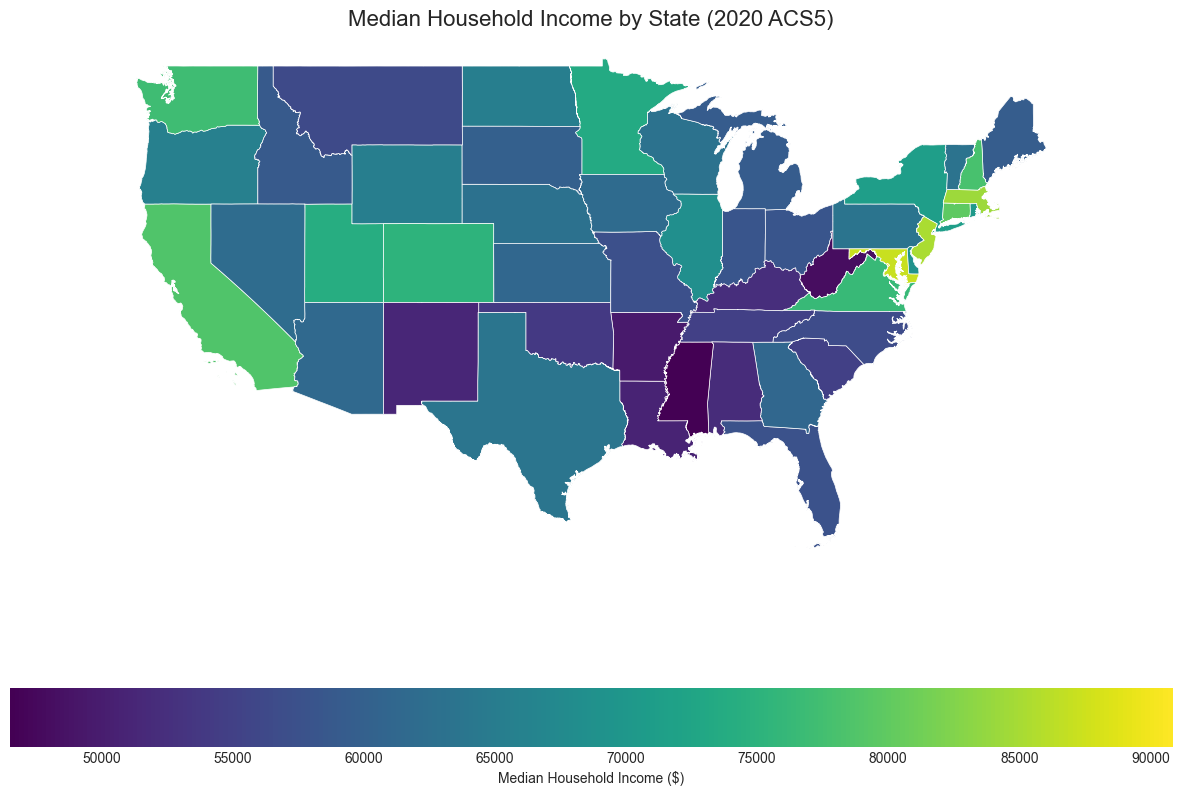

In [7]:
print("🗺️ Visualizing Median Household Income (State Level)...")

# Filter for contiguous US for better plotting (exclude AK, HI, PR for this specific plot)
# State FIPS: AK=02, HI=15, PR=72
contiguous_us = gdf_state[~gdf_state['STATE'].isin(['02', '15', '72'])].copy()

fig, ax = plt.subplots(figsize=(15, 10))

contiguous_us.plot(
    column='Median_Household_Income',
    cmap='viridis',
    legend=True,
    legend_kwds={'label': "Median Household Income ($)", 'orientation': "horizontal"},
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)

ax.set_title("Median Household Income by State (2020 ACS5)", fontsize=16)
ax.axis('off')
plt.show()

### 3.2 Puerto Rico Analysis

Since our project has a specific interest in Puerto Rico (from previous notebooks), let's visualize it specifically at the County (Municipio) level.

🗺️ Visualizing Puerto Rico (County/Municipio Level)...


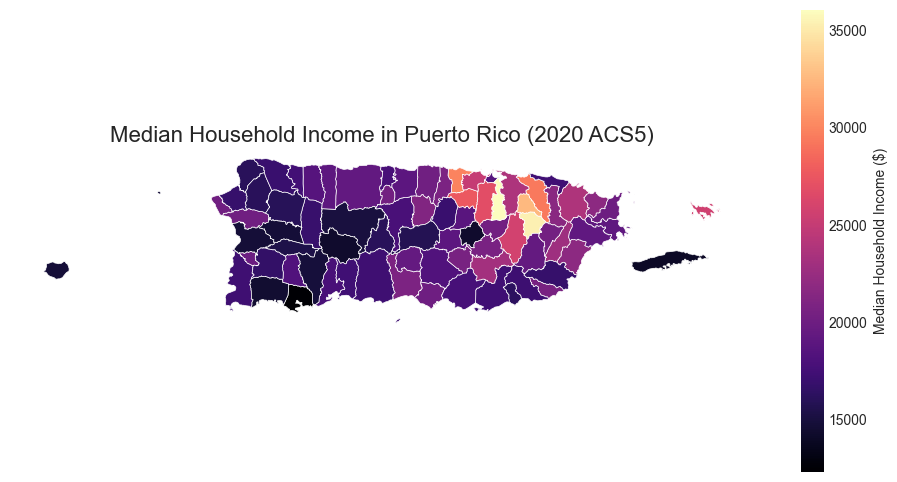

In [8]:
print("🗺️ Visualizing Puerto Rico (County/Municipio Level)...")

# Filter for Puerto Rico (State 72)
pr_counties = gdf_county[gdf_county['STATE'] == '72'].copy()

fig, ax = plt.subplots(figsize=(12, 6))

pr_counties.plot(
    column='Median_Household_Income',
    cmap='magma',
    legend=True,
    legend_kwds={'label': "Median Household Income ($)"},
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgrey', 'label': 'Missing Data'},
    ax=ax
)

ax.set_title("Median Household Income in Puerto Rico (2020 ACS5)", fontsize=16)
ax.axis('off')
plt.show()

---

## 💾 Part 4: Saving Data to DuckDB

We will save these datasets to our local DuckDB database (`db/pv_project.ddb`).
We will store them as separate tables:
-   `census_acs5_state_2020`
-   `census_acs5_county_2020`

We are **not** joining them with the PV data yet. That will happen in a future analysis step.

In [ ]:
print("💾 Saving Census Data to DuckDB...")

DB_PATH = os.getenv('PROJECT_DB', 'db/pv_project.ddb')
con = duckdb.connect(DB_PATH)
con.execute("INSTALL spatial; LOAD spatial;")

# 1. Save State Data
# Convert geometry to WKT for storage
state_save = gdf_state.copy()
state_save['geometry'] = state_save['geometry'].apply(lambda x: x.wkt)
con.execute("CREATE OR REPLACE TABLE census_acs5_state_2020 AS SELECT * FROM state_save")
print("   ✅ Saved 'census_acs5_state_2020'")

# 2. Save County Data
county_save = gdf_county.copy()
county_save['geometry'] = county_save['geometry'].apply(lambda x: x.wkt)
con.execute("CREATE OR REPLACE TABLE census_acs5_county_2020 AS SELECT * FROM county_save")
print("   ✅ Saved 'census_acs5_county_2020'")

# Verify
tables = con.execute("SHOW TABLES").fetchall()
print(f"   Tables in DB: {[t[0] for t in tables]}")

con.close()

💾 Saving Census Data to DuckDB...


/var/folders/71/3fjqkxbs6w3frshvsfj30fmm0000gn/T/ipykernel_7984/140273093.py:10: UserWarning: Geometry column does not contain geometry.
  state_save['geometry'] = state_save['geometry'].apply(lambda x: x.wkt)
/var/folders/71/3fjqkxbs6w3frshvsfj30fmm0000gn/T/ipykernel_7984/140273093.py:16: UserWarning: Geometry column does not contain geometry.
  county_save['geometry'] = county_save['geometry'].apply(lambda x: x.wkt)


   ✅ Saved 'census_acs5_state_2020'
   ✅ Saved 'census_acs5_county_2020'
   Tables in DB: ['admin_div_geom', 'administrative_divisions', 'census_acs5_county_2020', 'census_acs5_state_2020', 'processed_pv_data']


: 

## 🎓 Summary

In this notebook, we:
1.  **Explored** `censusdis` for fetching US Census data.
2.  **Fetched** ACS 5-Year Estimates for 2020 for the entire US and Puerto Rico.
3.  **Visualized** income distribution at State and County levels.
4.  **Persisted** the raw census data to DuckDB for future integration.

This data will be crucial for analyzing the socioeconomic context of solar panel adoption in our final project.